In [1]:
import pandas as pd
import numpy as np

# Load just 500k rows to keep it fast for exploration
df = pd.read_csv('../data/2019-Oct.csv', 
                 parse_dates=['event_time'],
                 nrows=500000)

print(f"Rows loaded: {df.shape[0]:,}")
print(f"\n=== Column types ===")
print(df.dtypes)
print(f"\n=== Null counts ===")
print(df.isnull().sum())
print(f"\n=== Event type distribution ===")
print(df['event_type'].value_counts())
print(f"\n=== Sample rows ===")
print(df.head(3).to_string())

Rows loaded: 500,000

=== Column types ===
event_time       datetime64[ns, UTC]
event_type                    object
product_id                     int64
category_id                    int64
category_code                 object
brand                         object
price                        float64
user_id                        int64
user_session                  object
dtype: object

=== Null counts ===
event_time            0
event_type            0
product_id            0
category_id           0
category_code    158439
brand             71851
price                 0
user_id               0
user_session          0
dtype: int64

=== Event type distribution ===
event_type
view        481833
purchase      9758
cart          8409
Name: count, dtype: int64

=== Sample rows ===
                 event_time event_type  product_id          category_id                        category_code     brand   price    user_id                          user_session
0 2019-10-01 00:00:00+00:00       vi

In [2]:
# ── Funnel overview ────────────────────────────────────────
total = len(df)
event_counts = df['event_type'].value_counts()

print("=== Event type counts ===")
print(event_counts)
print()

# Conversion rates
views     = event_counts.get('view', 0)
carts     = event_counts.get('cart', 0)
purchases = event_counts.get('purchase', 0)

print("=== Top-level funnel rates ===")
print(f"View → Cart:     {carts/views*100:.2f}%")
print(f"Cart → Purchase: {purchases/carts*100:.2f}%")
print(f"View → Purchase: {purchases/views*100:.2f}%")
print()

# Category code sample
print("=== Sample category_code values ===")
print(df['category_code'].dropna().unique()[:20])

=== Event type counts ===
event_type
view        481833
purchase      9758
cart          8409
Name: count, dtype: int64

=== Top-level funnel rates ===
View → Cart:     1.75%
Cart → Purchase: 116.04%
View → Purchase: 2.03%

=== Sample category_code values ===
['appliances.environment.water_heater' 'furniture.living_room.sofa'
 'computers.notebook' 'electronics.smartphone' 'computers.desktop'
 'apparel.shoes.keds' 'appliances.kitchen.microwave'
 'furniture.bedroom.bed' 'electronics.video.tv' 'appliances.kitchen.mixer'
 'electronics.audio.headphone' 'appliances.environment.air_heater'
 'apparel.shoes' 'appliances.environment.vacuum'
 'appliances.kitchen.refrigerators' 'appliances.kitchen.washer'
 'computers.peripherals.monitor' 'construction.tools.pump'
 'electronics.clocks' 'apparel.shoes.slipons']


In [3]:
# ── Phase 2: Cleaning ──────────────────────────────────────

# 1. Split category_code into three level columns
df[['cat_l1', 'cat_l2', 'cat_l3']] = df['category_code'].str.split('.', expand=True, n=2).reindex(columns=[0,1,2])

# 2. Create a clean version for category-level analysis (drop null category_code)
df_cat = df.dropna(subset=['category_code']).copy()

# 3. Create a clean version for brand-level analysis (drop null brand)
df_brand = df.dropna(subset=['brand']).copy()

# 4. Parse hour and day of week from event_time
df['hour'] = df['event_time'].dt.hour
df['day_of_week'] = df['event_time'].dt.day_name()

print(f"Full sample:           {len(df):,} rows")
print(f"With category_code:    {len(df_cat):,} rows")
print(f"With brand:            {len(df_brand):,} rows")
print()

print("=== Top 10 level-1 categories ===")
print(df_cat['cat_l1'].value_counts().head(10))
print()

print("=== Top 10 brands ===")
print(df_brand['brand'].value_counts().head(10))

Full sample:           500,000 rows
With category_code:    341,561 rows
With brand:            428,149 rows

=== Top 10 level-1 categories ===
cat_l1
electronics     191696
appliances       59624
computers        28663
apparel          14431
furniture        13352
auto             12571
construction      9548
kids              6380
accessories       2703
sport             2068
Name: count, dtype: int64

=== Top 10 brands ===
brand
samsung    60975
apple      52349
xiaomi     34834
huawei     13731
lucente     8633
bosch       6533
lg          5199
sony        4829
acer        4814
lenovo      4575
Name: count, dtype: int64


In [4]:
# ── Phase 3a: Funnel by category (the main analysis) ──────

funnel = (
    df_cat.groupby(['cat_l1', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'view': 'views', 'cart': 'carts', 'purchase': 'purchases'})
)

# Make sure all three columns exist
for col in ['views', 'carts', 'purchases']:
    if col not in funnel.columns:
        funnel[col] = 0

# Calculate conversion rates
funnel['view_to_cart_pct']     = (funnel['carts']     / funnel['views']  * 100).round(2)
funnel['cart_to_purchase_pct'] = (funnel['purchases'] / funnel['carts']  * 100).round(2)
funnel['view_to_purchase_pct'] = (funnel['purchases'] / funnel['views']  * 100).round(2)

# Sort by total views descending
funnel = funnel.sort_values('views', ascending=False)

print("=== Funnel conversion rates by category ===")
print(funnel[['views', 'carts', 'purchases', 
              'view_to_cart_pct', 
              'cart_to_purchase_pct', 
              'view_to_purchase_pct']].to_string())

=== Funnel conversion rates by category ===
event_type     views  carts  purchases  view_to_cart_pct  cart_to_purchase_pct  view_to_purchase_pct
cat_l1                                                                                              
electronics   179017   6983       5696              3.90                 81.57                  3.18
appliances     58296    318       1010              0.55                317.61                  1.73
computers      28177     73        413              0.26                565.75                  1.47
apparel        14362      0         69              0.00                   inf                  0.48
furniture      13255      5         92              0.04               1840.00                  0.69
auto           12367     88        116              0.71                131.82                  0.94
construction    9342     85        121              0.91                142.35                  1.30
kids            6288     13         79         

In [5]:
# ── Phase 3b: Funnel by brand (top 15 only) ───────────────

top_brands = df_brand['brand'].value_counts().head(15).index

brand_funnel = (
    df_brand[df_brand['brand'].isin(top_brands)]
    .groupby(['brand', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'view': 'views', 'cart': 'carts', 'purchase': 'purchases'})
)

for col in ['views', 'carts', 'purchases']:
    if col not in brand_funnel.columns:
        brand_funnel[col] = 0

brand_funnel['view_to_cart_pct']     = (brand_funnel['carts']     / brand_funnel['views'] * 100).round(2)
brand_funnel['view_to_purchase_pct'] = (brand_funnel['purchases'] / brand_funnel['views'] * 100).round(2)
brand_funnel['avg_price'] = (
    df_brand[df_brand['brand'].isin(top_brands)]
    .groupby('brand')['price'].mean().round(2)
)

brand_funnel = brand_funnel.sort_values('view_to_purchase_pct', ascending=False)

print("=== Funnel conversion by brand (sorted by view-to-purchase) ===")
print(brand_funnel[['views', 'purchases', 
                     'view_to_cart_pct',
                     'view_to_purchase_pct', 
                     'avg_price']].to_string())

=== Funnel conversion by brand (sorted by view-to-purchase) ===
event_type  views  purchases  view_to_cart_pct  view_to_purchase_pct  avg_price
brand                                                                          
samsung     55466       2385              5.63                  4.30     333.54
apple       48123       1954              4.72                  4.06     868.03
oppo         3818        111              4.43                  2.91     289.06
huawei      12911        343              3.69                  2.66     261.55
elenberg     3606         92              0.00                  2.55      54.11
xiaomi      32816        752              3.86                  2.29     193.36
lg           5030        111              1.15                  2.21     450.28
artel        4176         89              1.01                  2.13     158.21
lucente      8463        170              0.00                  2.01     262.47
acer         4713         87              0.30          

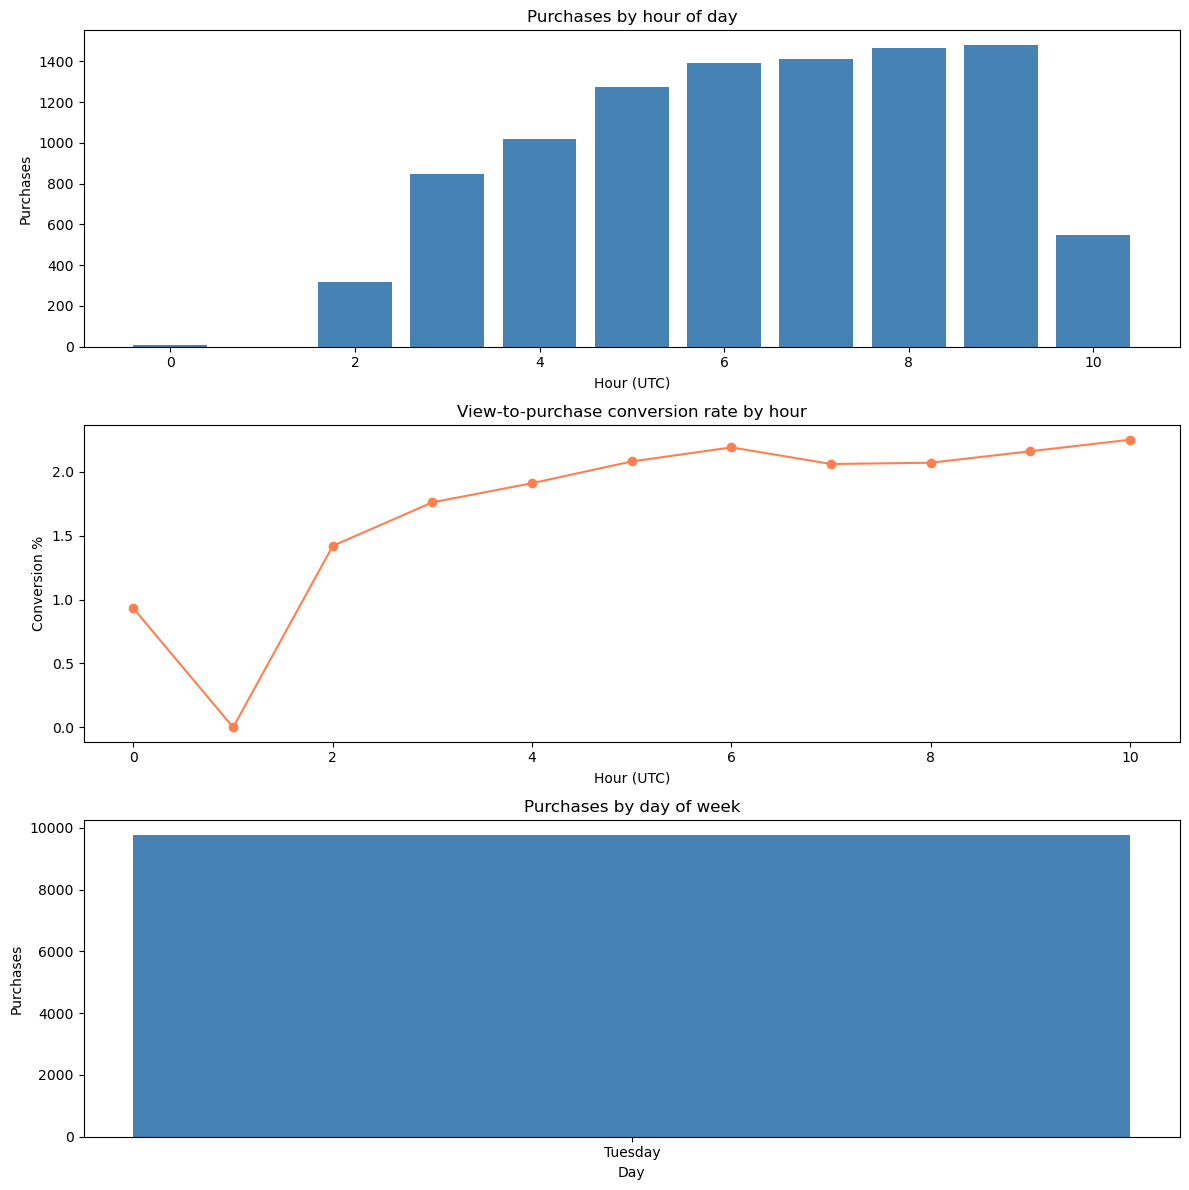


=== Conversion rate by hour ===
hour
0     0.93
1     0.00
2     1.42
3     1.76
4     1.91
5     2.08
6     2.19
7     2.06
8     2.07
9     2.16
10    2.25


In [6]:
# ── Phase 3c: Time patterns ────────────────────────────────

import matplotlib.pyplot as plt

# Purchases by hour of day
purchases_by_hour = (
    df[df['event_type'] == 'purchase']
    .groupby('hour')
    .size()
    .reset_index(name='purchases')
)

# Purchases by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
purchases_by_day = (
    df[df['event_type'] == 'purchase']
    .groupby('day_of_week')
    .size()
    .reindex(day_order)
    .reset_index(name='purchases')
)

# Conversion rate by hour (purchases / views per hour)
conv_by_hour = (
    df.groupby(['hour', 'event_type'])
    .size()
    .unstack(fill_value=0)
)
conv_by_hour['conversion_pct'] = (
    conv_by_hour['purchase'] / conv_by_hour['view'] * 100
).round(2)

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: purchases by hour
axes[0].bar(purchases_by_hour['hour'], purchases_by_hour['purchases'], color='steelblue')
axes[0].set_title('Purchases by hour of day')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Purchases')

# Plot 2: conversion rate by hour
axes[1].plot(conv_by_hour.index, conv_by_hour['conversion_pct'], marker='o', color='coral')
axes[1].set_title('View-to-purchase conversion rate by hour')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Conversion %')

# Plot 3: purchases by day of week
axes[2].bar(purchases_by_day['day_of_week'], purchases_by_day['purchases'], color='steelblue')
axes[2].set_title('Purchases by day of week')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Purchases')

plt.tight_layout()
plt.savefig('../data/time_patterns.png', dpi=150)
plt.show()

print("\n=== Conversion rate by hour ===")
print(conv_by_hour['conversion_pct'].to_string())

In [7]:
# ── Phase 3d: Time to convert (view → purchase) ────────────

# Get first view and first purchase per user per product
views_df = (
    df[df['event_type'] == 'view']
    .groupby(['user_id', 'product_id'])['event_time']
    .min()
    .reset_index()
    .rename(columns={'event_time': 'first_view'})
)

purchases_df = (
    df[df['event_type'] == 'purchase']
    .groupby(['user_id', 'product_id'])['event_time']
    .min()
    .reset_index()
    .rename(columns={'event_time': 'first_purchase'})
)

# Merge to get pairs where same user viewed then purchased same product
journey = views_df.merge(purchases_df, on=['user_id', 'product_id'])
journey['hours_to_convert'] = (
    (journey['first_purchase'] - journey['first_view'])
    .dt.total_seconds() / 3600
)

# Keep only positive values (purchase after view)
journey = journey[journey['hours_to_convert'] >= 0]

print(f"View → purchase journeys found: {len(journey):,}")
print(f"\n=== Time to convert (hours) ===")
print(journey['hours_to_convert'].describe().round(2))
print(f"\nMedian hours to convert: {journey['hours_to_convert'].median():.2f}")
print(f"% converting within 1 hour:  {(journey['hours_to_convert'] <= 1).mean()*100:.1f}%")
print(f"% converting within 24 hours: {(journey['hours_to_convert'] <= 24).mean()*100:.1f}%")

# By category
journey_cat = journey.merge(
    df[['user_id','product_id','cat_l1']].drop_duplicates(),
    on=['user_id','product_id'],
    how='left'
)

print(f"\n=== Median hours to convert by category ===")
print(journey_cat.groupby('cat_l1')['hours_to_convert'].median().sort_values().round(2))

View → purchase journeys found: 8,527

=== Time to convert (hours) ===
count    8527.00
mean        0.23
std         0.67
min         0.00
25%         0.02
50%         0.04
75%         0.10
max        10.11
Name: hours_to_convert, dtype: float64

Median hours to convert: 0.04
% converting within 1 hour:  94.4%
% converting within 24 hours: 100.0%

=== Median hours to convert by category ===
cat_l1
sport           0.03
electronics     0.04
computers       0.04
kids            0.04
furniture       0.05
apparel         0.05
stationery      0.05
accessories     0.05
auto            0.05
appliances      0.06
construction    0.07
medicine        0.08
country_yard    0.10
Name: hours_to_convert, dtype: float64


In [8]:
# ── Phase 4: Save cleaned data for SQL work ────────────────

# Save a small sample to use for SQL query development
df.head(50000).to_csv('../data/sample_50k.csv', index=False)
print("Saved sample_50k.csv")

Saved sample_50k.csv
